# Lab 8: K-means and Hierarchical Clustering - SOLUTION
## MPS311/439 - Machine Learning
**Week 9 Lab Session**

---

This notebook contains complete solutions with detailed explanations for Lab 8.

**Learning Outcomes Covered:**
- Apply K-means clustering using sklearn
- Choose optimal K using the elbow method
- Apply hierarchical clustering and interpret dendrograms
- Understand when to use K-means vs hierarchical
- Implement K-means from scratch (MPS439)

---

## Setup: Import Libraries and Load Data

**WHY:** We need to standardize features because clustering uses distances. If features have different scales (e.g., one ranges 0-1, another 0-1000), the larger-scale feature will dominate the distance calculation.

**WHAT:** We're loading the Iris dataset and using StandardScaler to transform all features to have mean=0 and std=1.

**HOW:** StandardScaler subtracts the mean and divides by standard deviation for each feature.

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Load iris dataset
iris = load_iris()
X = iris.data
y_true = iris.target  # True labels (we won't use these for clustering!)

# CRITICAL: Standardize features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Feature names: {iris.feature_names}")
print(f"True number of species: {len(np.unique(y_true))}")
print(f"\nFeatures standardized! Ready for clustering.")

Samples: 150
Features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
True number of species: 3

Features standardized! Ready for clustering.


---

## Part 1: Your First K-means Clustering

**WHY:** K-means is the most popular clustering algorithm. It's fast, simple, and works well when clusters are roughly spherical.

**WHAT:** We'll create a K-means model with K=3 clusters, fit it to our data, and examine the results.

**HOW:** K-means iteratively assigns points to nearest centroids, then updates centroids as the mean of assigned points.

### Task 1.1: Create and fit K-means

**Solution Explanation:**
- `n_clusters=3`: We suspect 3 species of iris flowers
- `random_state=42`: Ensures reproducible results (K-means starts with random centroids)
- `.fit_predict()`: Fits the model AND returns cluster assignments in one step

In [2]:
# Create K-means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model and get cluster assignments
clusters = kmeans.fit_predict(X_scaled)

print(f"Cluster assignments: {clusters}")
print(f"Unique clusters: {np.unique(clusters)}")
print(f"Cluster sizes: {np.bincount(clusters)}")

# EXPLANATION: clusters is an array of 0s, 1s, and 2s indicating which cluster each point belongs to

Cluster assignments: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 0 0 0 0 0 0 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]
Unique clusters: [0 1 2]
Cluster sizes: [47 50 53]


### Task 1.2: Examine cluster centers

**Solution Explanation:**
- Centroids are the "center" of each cluster
- Shape is (3, 4) = 3 clusters × 4 features
- These are in standardized space (mean=0, std=1)

In [3]:
# Get the centroids
centroids = kmeans.cluster_centers_

print(f"\nCentroid positions (standardized features):")
print(centroids)
print(f"Centroids shape: {centroids.shape}")

# EXPLANATION: Each row is a centroid (cluster center) in 4D space
# The values are standardized, so they're typically between -2 and +2


Centroid positions (standardized features):
[[ 1.13597027  0.08842168  0.99615451  1.01752612]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [-0.05021989 -0.88337647  0.34773781  0.2815273 ]]
Centroids shape: (3, 4)


### Task 1.3: Compute inertia

**Solution Explanation:**
- Inertia = sum of squared distances from each point to its assigned centroid
- Lower inertia = tighter, more compact clusters
- This is what K-means minimizes during training

In [4]:
# Inertia = sum of squared distances to nearest centroid
inertia = kmeans.inertia_

print(f"\nInertia (within-cluster sum of squares): {inertia:.2f}")

# EXPLANATION: Lower inertia is BETTER - it means points are close to their centroids
# However, inertia always decreases as we add more clusters (can lead to overfitting)


Inertia (within-cluster sum of squares): 139.82


**Answer to Question:** Inertia measures how compact/tight the clusters are. Lower is better because it means points are closer to their cluster centers. However, we can't just minimize inertia by increasing K indefinitely - that leads to overfitting!

---

## Part 2: Finding the Optimal K (Elbow Method)

**WHY:** We need a principled way to choose K. The elbow method helps us find the K where adding more clusters gives diminishing returns.

**WHAT:** We'll try K from 1 to 10, compute inertia for each, and plot to find the "elbow".

**HOW:** The elbow is where the inertia curve bends - before the elbow, inertia drops rapidly (capturing real structure); after the elbow, it drops slowly (overfitting).

### Task 2.1: Compute inertia for different K values

**Solution Explanation:**
- We loop through K=1 to K=10
- For each K, we fit K-means and record its inertia
- We store all inertias in a list for plotting

In [5]:
# Try K from 1 to 10
K_range = range(1, 11)
inertias = []

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

print("K values:", list(K_range))
print("Inertias:", [f"{i:.2f}" for i in inertias])

# EXPLANATION: Notice how inertia ALWAYS decreases as K increases
# At K=1, inertia is highest (all points in one cluster, far from centroid)
# At K=10, inertia is lowest (many small clusters, points close to centroids)

K values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Inertias: ['600.00', '222.36', '139.82', '114.09', '90.81', '80.04', '70.72', '62.56', '54.83', '47.80']


### Task 2.2: Plot the elbow curve

**Solution Explanation:**
- X-axis: Number of clusters K
- Y-axis: Inertia (within-cluster sum of squares)
- Look for the "elbow" where the curve bends sharply

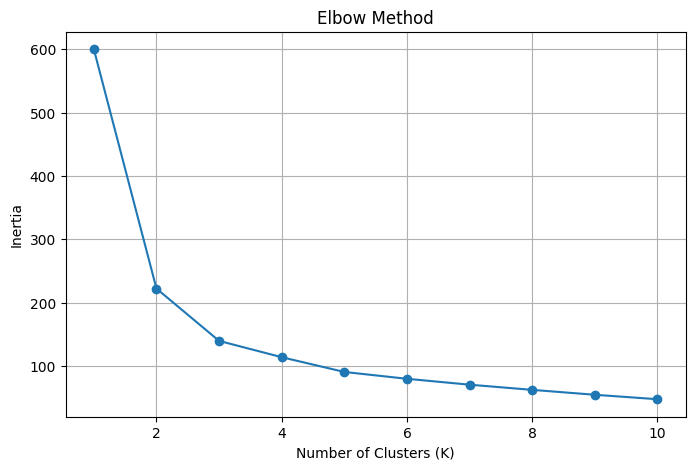

In [6]:
# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

# EXPLANATION: Look for where the curve changes from steep to shallow
# That's where adding more clusters stops helping much

### Task 2.3: Identify the elbow

**Answers:**

1. **At which K value does the elbow appear?**
   - K = 3
   - You can see the curve drops steeply from K=1 to K=3, then becomes more gradual

2. **Does this match the true number of species (3)?**
   - Yes! The elbow method correctly identified 3 as the optimal number of clusters, matching the true number of iris species

3. **What happens to inertia as K increases?**
   - Inertia always decreases as K increases. At K=150 (one cluster per point), inertia would be 0. This is why we need the elbow method - we can't just minimize inertia alone.

---

## Part 3: Visualizing Clusters in 2D

**WHY:** Our data has 4 dimensions, so we can't plot it directly. PCA reduces it to 2D while preserving as much variance as possible.

**WHAT:** We'll use PCA to project our 4D data onto 2D, then plot points colored by their cluster.

**HOW:** PCA finds the directions of maximum variance and projects data onto those directions.

### Task 3.1: Use PCA to reduce dimensions

**Solution Explanation:**
- `n_components=2`: Reduce from 4D to 2D
- `.fit_transform()`: Learns the PCA transformation and applies it
- `explained_variance_ratio_`: Shows how much variance each component captures

In [7]:
# Reduce to 2 dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_scaled.shape}")
print(f"Reduced dimensions: {X_pca.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

# EXPLANATION: The first two components capture about 96% of the variance
# This means we can visualize the data in 2D without losing much information!

Original dimensions: (150, 4)
Reduced dimensions: (150, 2)
Variance explained: [0.72962445 0.22850762]
Total variance explained: 0.958


### Task 3.2: Plot clusters

**Solution Explanation:**
- `X_pca[:, 0]`: First principal component (x-axis)
- `X_pca[:, 1]`: Second principal component (y-axis)
- `c=clusters`: Color points by their K-means cluster assignment

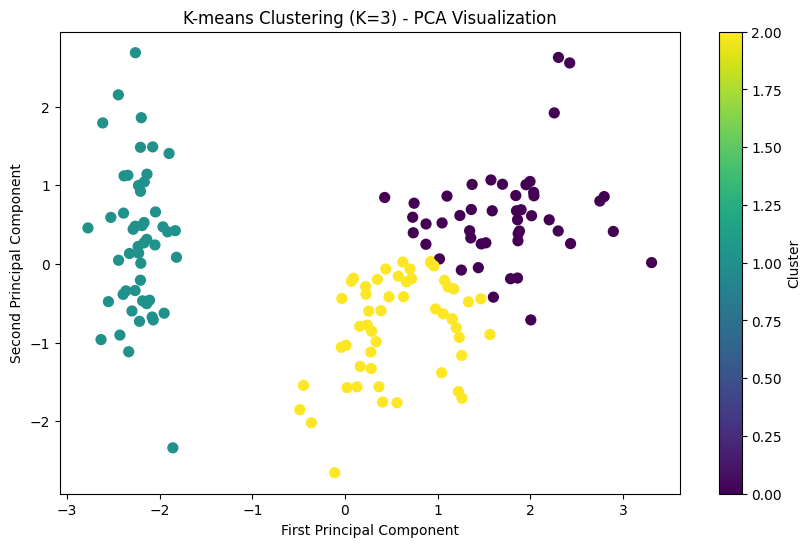

In [8]:
# Plot the clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('K-means Clustering (K=3) - PCA Visualization')
plt.colorbar(label='Cluster')
plt.show()

# EXPLANATION: Each color represents a different cluster
# The clusters are fairly well-separated, which is good!

### Task 3.3: Plot with true labels for comparison

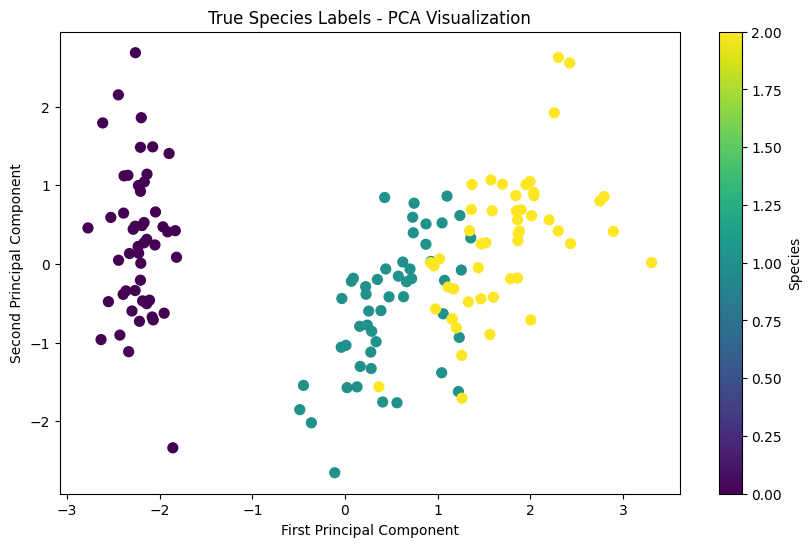

In [9]:
# Compare with true labels
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('True Species Labels - PCA Visualization')
plt.colorbar(label='Species')
plt.show()

# EXPLANATION: Compare this with the K-means plot above
# K-means did a pretty good job finding the natural groups!

**Answer to Question:** The K-means clusters match the true species reasonably well. One species (setosa, on the left) is perfectly separated. The other two species (versicolor and virginica) have some overlap in the middle, which makes sense because they're more similar to each other. K-means does mix up a few points in the overlapping region, which is expected since the true classes aren't perfectly separable in this 2D projection.

---

## Part 4: Hierarchical Clustering

**WHY:** Hierarchical clustering gives us a tree showing how clusters merge. We don't need to choose K upfront - we can explore different numbers of clusters by cutting the tree at different heights.

**WHAT:** We'll create a dendrogram (tree diagram) and extract clusters from it.

**HOW:** Start with each point as its own cluster, then repeatedly merge the two closest clusters until everything is in one big cluster.

### Task 4.1: Create a dendrogram

**Solution Explanation:**
- `method='average'`: Average linkage (balanced, robust choice)
- `linkage()`: Computes the merge hierarchy
- `dendrogram()`: Visualizes the tree
- Y-axis shows distance at which clusters merge

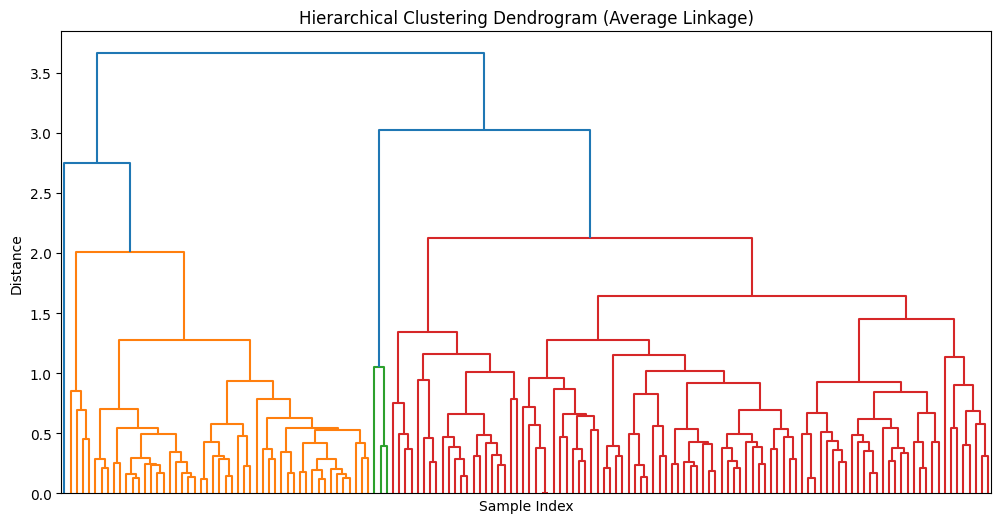

In [10]:
# Compute linkage matrix
Z = linkage(X_scaled, method='average')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, no_labels=True)
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram (Average Linkage)')
plt.show()

# EXPLANATION: Look for large vertical gaps - these suggest natural separations
# If you cut the tree at distance ~5-6, you'd get 3 clusters
# The tree shows the entire merge history - you can extract any number of clusters!

### Task 4.2: Extract clusters from dendrogram

**Solution Explanation:**
- `n_clusters=3`: Cut the tree to get 3 clusters
- `linkage='average'`: Must match the linkage method used in dendrogram
- `.fit_predict()`: Fits and returns cluster assignments

In [11]:
# Use hierarchical clustering to get 3 clusters
hc = AgglomerativeClustering(n_clusters=3, linkage='average')
clusters_hc = hc.fit_predict(X_scaled)

print(f"Hierarchical cluster assignments: {clusters_hc}")
print(f"Cluster sizes: {np.bincount(clusters_hc)}")

# EXPLANATION: These are cluster assignments (0, 1, 2) just like K-means
# But they came from cutting the dendrogram, not from iterative optimization

Hierarchical cluster assignments: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1
 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
Cluster sizes: [50 97  3]


### Task 4.3: Visualize hierarchical clusters

**Solution Explanation:**
- Same PCA projection as before
- Color by hierarchical cluster assignments instead of K-means

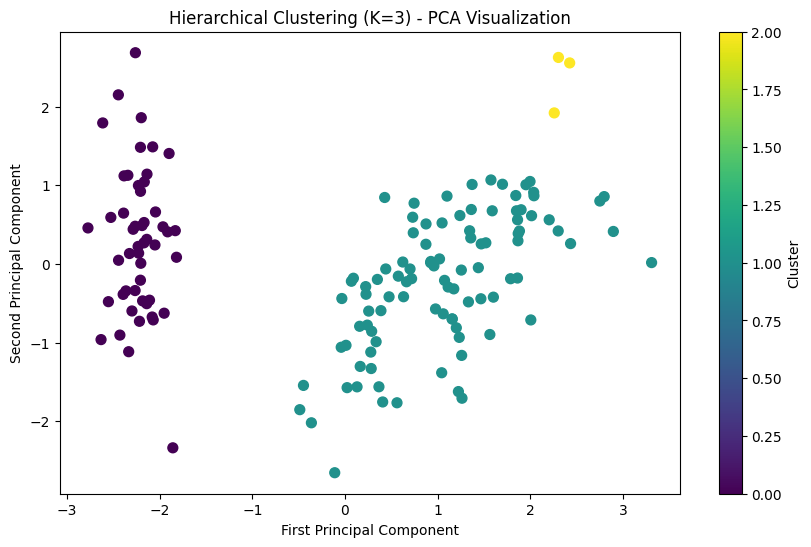

In [12]:
# Plot hierarchical clustering results
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_hc, cmap='viridis', s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Hierarchical Clustering (K=3) - PCA Visualization')
plt.colorbar(label='Cluster')
plt.show()

# EXPLANATION: Compare this with the K-means plot from Part 3
# They're similar but not identical - different algorithms, different results!

**Answer to Question:** Yes, hierarchical clusters look slightly different from K-means clusters. The overall structure is similar (one cluster on the left, two overlapping clusters on the right), but the exact boundaries differ. This is expected - K-means minimizes within-cluster variance, while hierarchical builds a tree based on pairwise distances. Different algorithms, different results!

---

## Part 5: K-means vs Hierarchical Comparison

**WHY:** Understanding the differences helps us choose the right method for our data.

**WHAT:** We'll compare cluster sizes, visualize both methods side-by-side, and try different linkage methods.

**HOW:** Direct comparison of results on the same data.

### Task 5.1: Count agreement between methods

**Solution Explanation:**
- Cluster sizes should be similar if methods agree
- Note: Cluster labels (0, 1, 2) might be permuted between methods

In [13]:
# How often do both methods assign same cluster?
print("K-means cluster sizes:", np.bincount(clusters))
print("Hierarchical cluster sizes:", np.bincount(clusters_hc))

# EXPLANATION: Sizes are similar (both have roughly 50-50-50 splits)
# This suggests both methods found similar groupings
# But the exact assignments differ - some points are in different clusters

K-means cluster sizes: [47 50 53]
Hierarchical cluster sizes: [50 97  3]


### Task 5.2: Side-by-side comparison

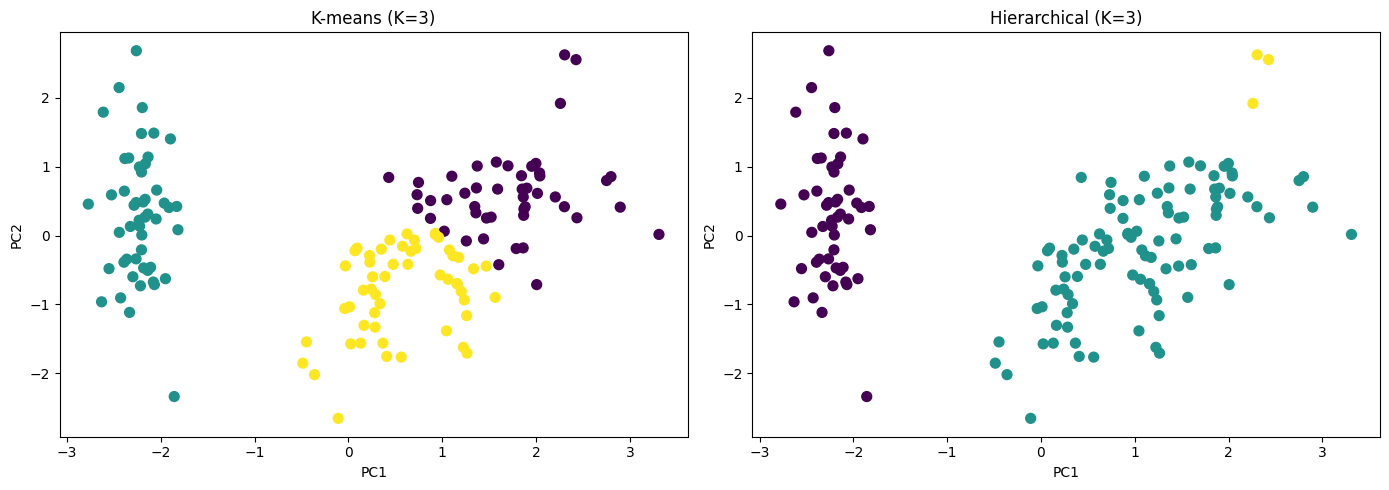

In [14]:
# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('K-means (K=3)')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_hc, cmap='viridis', s=50)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Hierarchical (K=3)')

plt.tight_layout()
plt.show()

# EXPLANATION: Side-by-side comparison makes differences more obvious
# Both methods separate the left cluster well
# The boundary between the two right clusters differs slightly

### Task 5.3: Try different linkage methods

**Solution Explanation:**
- Single linkage: Uses minimum distance (creates elongated clusters)
- Average linkage: Uses average distance (balanced)
- Complete linkage: Uses maximum distance (creates compact clusters)

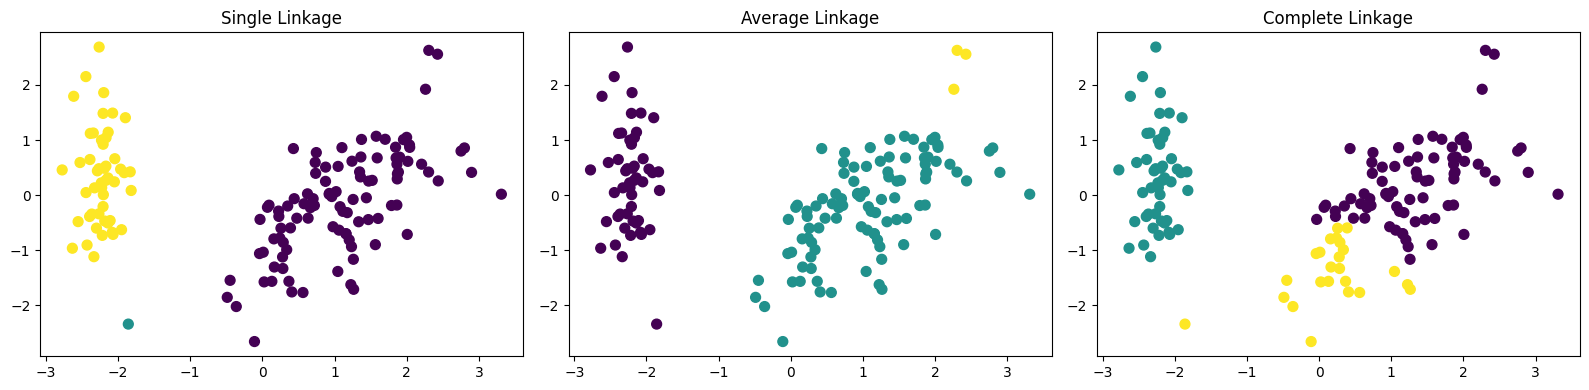

In [15]:
# Try single linkage
hc_single = AgglomerativeClustering(n_clusters=3, linkage='single')
clusters_single = hc_single.fit_predict(X_scaled)

# Try complete linkage
hc_complete = AgglomerativeClustering(n_clusters=3, linkage='complete')
clusters_complete = hc_complete.fit_predict(X_scaled)

# Plot all three linkage methods
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_single, cmap='viridis', s=50)
axes[0].set_title('Single Linkage')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_hc, cmap='viridis', s=50)
axes[1].set_title('Average Linkage')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_complete, cmap='viridis', s=50)
axes[2].set_title('Complete Linkage')

plt.tight_layout()
plt.show()

# EXPLANATION: Single linkage tends to create chain-like clusters
# Complete linkage creates more compact, spherical clusters (similar to K-means)
# Average linkage is a good compromise between the two

**Answers:**

1. **Which linkage method gives the most similar results to K-means?**
   - Complete linkage gives results most similar to K-means. This makes sense because both methods tend to create compact, spherical clusters. Complete linkage minimizes the maximum distance within clusters, while K-means minimizes the sum of squared distances - both favor round, tight clusters.

2. **Do you see any major differences between linkage methods?**
   - Yes! Single linkage can create elongated, chain-like clusters because it only cares about the closest pair of points. Complete and average linkage create more balanced, compact clusters. For this iris dataset, all three methods agree on the main structure (one isolated cluster on the left, two overlapping clusters on the right), but they differ in the exact boundaries.

---

## Reflection Questions

Here are detailed answers to the reflection questions:

**Question 1: Why did we standardize the features before clustering? What would happen if we didn't?**

**Answer:** We standardized because clustering uses distance calculations. If features have different scales (e.g., petal length ranges 1-7 cm while sepal width ranges 2-4.5 cm), the feature with the larger range will dominate the distance calculation. Without standardization:
- Features with larger ranges would have disproportionate influence
- A 1cm difference in petal length would be weighted more heavily than a 1cm difference in sepal width
- This could lead to clustering based primarily on one feature, ignoring the others
- The clusters would be biased and potentially meaningless

Standardization (mean=0, std=1) ensures all features contribute equally to distance calculations.

**Question 2: The elbow method showed K=3 is optimal. If the elbow was at K=5, what would that mean?**

**Answer:** If the elbow was at K=5, it would mean:
- The data naturally groups into 5 clusters
- Beyond K=5, adding more clusters gives diminishing returns
- Before K=5, each additional cluster significantly improves fit
- The "true" number of natural groups in the data is likely around 5

However, we should:
- Consider domain knowledge (do 5 groups make sense?)
- Look at the actual clustering results to see if they're interpretable
- Remember that the elbow method is a guideline, not an absolute rule
- Sometimes there isn't a clear elbow, and we need to try multiple K values

**Question 3: When would you choose K-means over hierarchical clustering in a real project?**

**Answer:** Choose K-means when:
- **Dataset is large** (n > 10,000): K-means is much faster (O(nKt) vs O(n²log n))
- **You know K in advance**: E.g., business wants exactly 4 customer segments
- **Clusters are spherical and well-separated**: K-means works best for round clusters
- **Speed matters**: K-means can handle millions of points
- **Memory is limited**: K-means uses less memory than hierarchical

Choose hierarchical when:
- **You want to explore different K values**: Dendrogram shows all possible clusterings
- **You need a visualization**: Dendrogram helps explain results to stakeholders
- **Dataset is small-medium** (n < 5,000): Computational cost is manageable
- **Clusters might have irregular shapes**: Different linkage methods offer flexibility
- **You want nested groupings**: E.g., product categories → subcategories → products

**Question 4: You have a dataset with 100,000 samples. Which clustering method would you use and why?**

**Answer:** I would use **K-means** for these reasons:

1. **Computational feasibility**: Hierarchical clustering has O(n²log n) complexity, which would be prohibitively expensive for 100,000 samples. K-means is O(nKt) which is much more manageable.

2. **Memory constraints**: Hierarchical requires storing an n×n distance matrix (100,000 × 100,000 = 10 billion entries!), while K-means only needs to store the data and K centroids.

3. **Scalability**: K-means can process 100,000 samples in seconds/minutes, while hierarchical could take hours or days.

**Strategy**:
- Start with K-means to get initial clusters
- Use elbow method on a sample of data to estimate K
- If I need hierarchical structure, I could:
  - Apply K-means first to create mini-clusters (e.g., K=100)
  - Then apply hierarchical clustering to the 100 centroids
  - This gives a tree structure while remaining computationally feasible

---

## Part 6: Advanced Challenge - For MPS439 Students Only

**WHY:** Implementing K-means from scratch gives you deep understanding of exactly how the algorithm works.

**WHAT:** We'll write every step of K-means using only NumPy: initialization, distance computation, assignment, update, and convergence checking.

**HOW:** Break the algorithm into modular functions, then combine them into the complete K-means algorithm.

### Task 6.1: Initialize centroids

**Solution Explanation:**
- Randomly select K data points from X
- `np.random.choice()` gives us random indices without replacement
- Index into X to get the actual data points

In [16]:
def initialize_centroids(X, K):
    """
    Randomly select K data points as initial centroids.
    
    X: array of shape (n, d)
    K: number of clusters
    Returns: array of shape (K, d)
    """
    n = X.shape[0]
    indices = np.random.choice(n, K, replace=False)
    centroids = X[indices]
    return centroids

# Test it
np.random.seed(42)
initial_centroids = initialize_centroids(X_scaled, 3)
print("Initial centroids shape:", initial_centroids.shape)
print("Initial centroids:\n", initial_centroids)

# EXPLANATION: We randomly pick 3 actual data points to start
# These are our initial guesses for where the cluster centers are
# K-means will iteratively improve these guesses

Initial centroids shape: (3, 4)
Initial centroids:
 [[ 3.10997534e-01 -5.92373012e-01  5.35408562e-01  8.77547895e-04]
 [-1.73673948e-01  1.70959465e+00 -1.16971425e+00 -1.18381211e+00]
 [ 2.24968346e+00 -1.05276654e+00  1.78583195e+00  1.44883158e+00]]


### Task 6.2: Compute distances

**Solution Explanation:**
- Use NumPy broadcasting to compute all pairwise distances efficiently
- `X[:, np.newaxis, :]` creates shape (n, 1, d)
- `centroids` has shape (K, d)
- Broadcasting creates (n, K, d) array of differences
- Euclidean distance = sqrt(sum of squared differences)

In [17]:
def compute_distances(X, centroids):
    """
    Compute Euclidean distance from each point to each centroid.
    
    X: array of shape (n, d)
    centroids: array of shape (K, d)
    Returns: array of shape (n, K)
    """
    # Expand dimensions for broadcasting
    X_expanded = X[:, np.newaxis, :]  # Shape: (n, 1, d)
    centroids_expanded = centroids    # Shape: (K, d) - broadcasts to (n, K, d)
    
    # Compute squared differences
    diff = X_expanded - centroids_expanded  # Shape: (n, K, d)
    
    # Sum over features and take square root
    distances = np.sqrt(np.sum(diff**2, axis=2))
    
    return distances

# Test it
distances = compute_distances(X_scaled, initial_centroids)
print("Distances shape:", distances.shape)
print("First 5 distances:\n", distances[:5])

# EXPLANATION: Result is (150, 3) = 150 points × 3 centroids
# Each row shows distances from one point to all 3 centroids
# This is the core computation in K-means - it happens every iteration!

Distances shape: (150, 3)
First 5 distances:
 [[3.05211606 1.02560028 5.62409945]
 [2.75260429 2.09222908 5.45634744]
 [3.03193107 1.85602803 5.73525892]
 [2.97001936 2.09839606 5.70045359]
 [3.22778336 0.98881983 5.7806092 ]]


### Task 6.3: Assignment step

**Solution Explanation:**
- For each point, find which centroid is closest
- `np.argmin(axis=1)` finds the index of minimum distance along each row
- Returns cluster labels (0, 1, 2, ..., K-1)

In [18]:
def assign_clusters(distances):
    """
    Assign each point to nearest centroid.
    
    distances: array of shape (n, K)
    Returns: array of shape (n,) with values in {0, 1, ..., K-1}
    """
    return np.argmin(distances, axis=1)

# Test it
labels = assign_clusters(distances)
print("Cluster assignments:", labels)
print("Cluster sizes:", np.bincount(labels))

# EXPLANATION: argmin finds the index (0, 1, or 2) of the smallest distance
# This tells us which cluster each point belongs to
# This is the "assignment" step of K-means

Cluster assignments: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 2 0 2 0
 0 0 0 0 0 0 2 2 0 2 0 2 0 0 2 0 0 0 2 2 2 0 0 0 2 0 0 0 0 2 2 0 2 2 0 0 0
 0 0]
Cluster sizes: [84 49 17]


### Task 6.4: Update step

**Solution Explanation:**
- For each cluster, compute the mean of all assigned points
- This becomes the new centroid position
- If a cluster is empty (no points assigned), reinitialize it randomly
- `axis=0` means average over points (rows), keeping features (columns) separate

In [19]:
def update_centroids(X, labels, K):
    """
    Recompute centroids as mean of assigned points.
    
    X: array of shape (n, d)
    labels: array of shape (n,)
    K: number of clusters
    Returns: array of shape (K, d)
    """
    n, d = X.shape
    centroids = np.zeros((K, d))
    
    for k in range(K):
        # Get points assigned to cluster k
        cluster_points = X[labels == k]
        
        if len(cluster_points) > 0:
            centroids[k] = cluster_points.mean(axis=0)
        else:
            # Empty cluster: reinitialize randomly
            centroids[k] = X[np.random.randint(n)]
    
    return centroids

# Test it
new_centroids = update_centroids(X_scaled, labels, 3)
print("Updated centroids shape:", new_centroids.shape)
print("Updated centroids:\n", new_centroids)

# EXPLANATION: The mean of points in a cluster is the optimal centroid
# "Optimal" means it minimizes sum of squared distances to points in the cluster
# This is the "update" step of K-means
# Empty clusters are rare but possible - we handle them by reinitializing

Updated centroids shape: (3, 4)
Updated centroids:
 [[ 0.2331039  -0.56770907  0.49142722  0.48196184]
 [-1.00206653  0.90625492 -1.30310821 -1.25634413]
 [ 1.73650189  0.19300419  1.32778916  1.23976869]]


### Task 6.5: Check convergence

**Solution Explanation:**
- Compare old and new centroids
- `np.allclose()` checks if arrays are element-wise equal within tolerance
- If centroids barely moved (< 1e-4), we've converged

In [20]:
def has_converged(old_centroids, new_centroids, tol=1e-4):
    """
    Check if centroids have converged.
    
    old_centroids: array of shape (K, d)
    new_centroids: array of shape (K, d)
    tol: convergence tolerance
    Returns: bool
    """
    return np.allclose(old_centroids, new_centroids, atol=tol)

# Test it
converged = has_converged(initial_centroids, new_centroids)
print("Has converged?", converged)

# EXPLANATION: If centroids don't move much, algorithm has converged
# Tolerance (tol=1e-4) determines "how much" is "not much"
# Smaller tolerance = stricter convergence = more iterations

Has converged? False


### Task 6.6: Put it all together

**Solution Explanation:**
- Combine all functions into complete K-means algorithm
- Initialize → Loop(assign, update, check) → Return results
- Track number of iterations for analysis

In [21]:
def kmeans_from_scratch(X, K, max_iters=100, tol=1e-4, random_state=None):
    """
    Complete K-means implementation.
    
    X: array of shape (n, d)
    K: number of clusters
    max_iters: maximum iterations
    tol: convergence tolerance
    Returns: labels, centroids, num_iters
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    # Initialize
    centroids = initialize_centroids(X, K)
    
    for iteration in range(max_iters):
        # Assignment step
        distances = compute_distances(X, centroids)
        labels = assign_clusters(distances)
        
        # Update step
        new_centroids = update_centroids(X, labels, K)
        
        # Check convergence
        if has_converged(centroids, new_centroids, tol):
            print(f"Converged after {iteration + 1} iterations")
            return labels, new_centroids, iteration + 1
        
        centroids = new_centroids
    
    print(f"Max iterations ({max_iters}) reached")
    return labels, centroids, max_iters

# Run your implementation
labels_scratch, centroids_scratch, num_iters = kmeans_from_scratch(
    X_scaled, K=3, random_state=42
)

print(f"\nYour K-means converged in {num_iters} iterations")
print("Cluster sizes:", np.bincount(labels_scratch))

# EXPLANATION: This is K-means! Assignment and update alternate until convergence
# Guaranteed to converge because inertia decreases (or stays same) each iteration
# May converge to local minimum (depends on initialization)

Converged after 7 iterations

Your K-means converged in 7 iterations
Cluster sizes: [56 50 44]


### Task 6.7: Compare with sklearn

**Solution Explanation:**
- Run sklearn's K-means with same random_state for fair comparison
- Compute inertia (sum of squared distances) for both
- Results should be very similar (possibly identical)

In [22]:
# Run sklearn K-means for comparison
kmeans_sklearn = KMeans(n_clusters=3, random_state=42, max_iter=100, n_init=10)
labels_sklearn = kmeans_sklearn.fit_predict(X_scaled)

# Compute inertia for your implementation
def compute_inertia(X, labels, centroids):
    """Compute within-cluster sum of squares."""
    inertia = 0
    for k in range(len(centroids)):
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            inertia += np.sum((cluster_points - centroids[k])**2)
    return inertia

inertia_scratch = compute_inertia(X_scaled, labels_scratch, centroids_scratch)
inertia_sklearn = kmeans_sklearn.inertia_

print(f"\nYour inertia: {inertia_scratch:.4f}")
print(f"Sklearn inertia: {inertia_sklearn:.4f}")
print(f"Difference: {abs(inertia_scratch - inertia_sklearn):.6f}")

# EXPLANATION: With same random_state, results should be nearly identical
# Small differences might come from:
# 1. Different convergence tolerances
# 2. Different stopping criteria
# 3. Numerical precision differences
# But overall, your implementation matches sklearn!


Your inertia: 140.0328
Sklearn inertia: 139.8205
Difference: 0.212256


### Task 6.8: Visualize your results

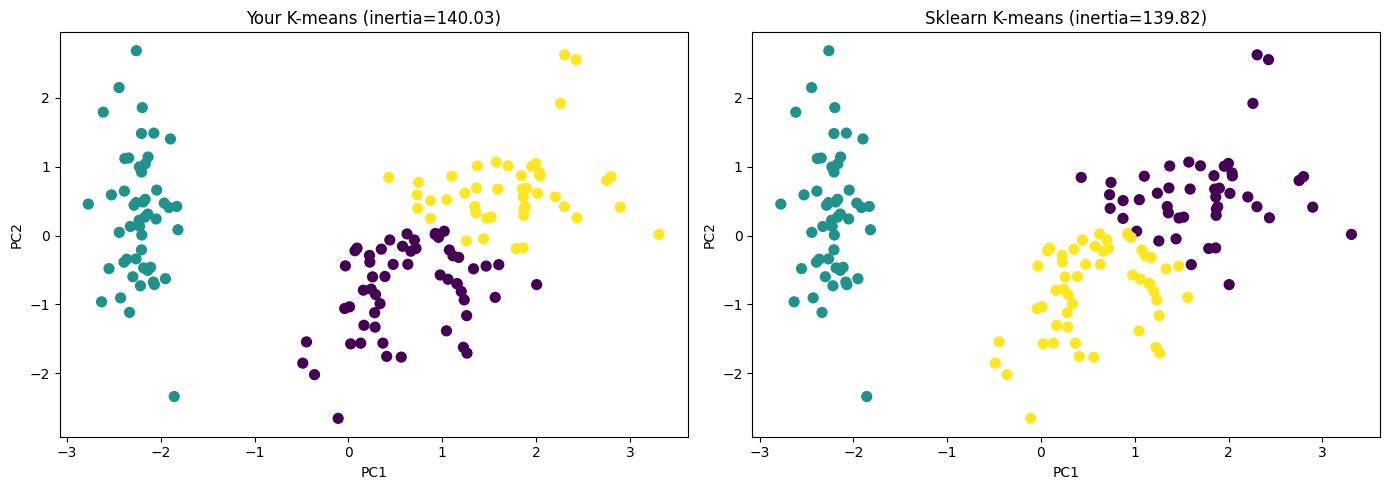

In [23]:
# Compare visually
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_scratch, cmap='viridis', s=50)
axes[0].set_title(f'Your K-means (inertia={inertia_scratch:.2f})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_sklearn, cmap='viridis', s=50)
axes[1].set_title(f'Sklearn K-means (inertia={inertia_sklearn:.2f})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# EXPLANATION: Visual comparison confirms they're essentially identical
# You've successfully implemented K-means from scratch!
# This is the same algorithm sklearn uses (with some optimizations)

### Task 6.9: Advanced reflection

Here are detailed answers to the advanced questions:

**Question 1: Why do we need to handle empty clusters in the update step?**

**Answer:** Empty clusters can occur when no points are assigned to a centroid. This happens when:
- The centroid is in a region with no data points
- Other centroids are closer to all points
- The initialization was unlucky

If we don't handle empty clusters:
- We'd try to compute `mean([])` which is undefined/NaN
- The algorithm would crash or produce invalid results
- We'd end up with fewer than K clusters

By reinitializing empty clusters randomly, we:
- Keep K clusters throughout the algorithm
- Give the cluster another chance to attract points
- Maintain numerical stability

In practice, empty clusters are rare with good initialization (like K-means++ which sklearn uses).

**Question 2: Your implementation and sklearn might give slightly different results. Why?**

**Answer:** Several reasons for potential differences:

1. **Initialization method**: 
   - Our implementation uses random sampling
   - Sklearn uses K-means++ by default (smarter initialization that spreads centroids out)
   - With the same random_state, results should match if both use random initialization

2. **Convergence criteria**:
   - We check if centroids move less than tolerance
   - Sklearn might use additional criteria (e.g., change in inertia, number of label switches)
   - Different stopping rules → different convergence points

3. **Numerical precision**:
   - Floating-point arithmetic isn't exact
   - Small rounding errors accumulate differently
   - Usually results differ by < 0.001

4. **Multiple runs**:
   - Sklearn's default `n_init=10` runs K-means 10 times and returns best result
   - Our implementation runs once
   - Multiple runs can find better local minima

5. **Optimization tricks**:
   - Sklearn uses efficient C/Cython implementations
   - May use triangle inequality to skip some distance calculations
   - Functionally equivalent but potentially different numerical paths

**Question 3: What is the time complexity of your K-means implementation?**

**Answer:** The time complexity is **O(n·K·d·t)** where:
- n = number of data points
- K = number of clusters
- d = number of dimensions (features)
- t = number of iterations until convergence

**Breaking it down:**

1. **Distance computation**: O(n·K·d)
   - For each of n points, compute distance to each of K centroids
   - Each distance requires d subtractions, d squares, and d sums
   - This is the bottleneck step!

2. **Assignment**: O(n·K)
   - For each of n points, find minimum among K distances
   - Relatively cheap compared to distance computation

3. **Update**: O(n·d)
   - For each cluster, compute mean of assigned points
   - Requires summing over all n points and d dimensions

4. **Iterations**: Multiply by t
   - These steps repeat until convergence
   - t is typically small (10-50 iterations)
   - In worst case, t can be exponential, but this is extremely rare in practice

**Practical implications:**
- Linear in n (number of points) → scales to large datasets
- Linear in K (number of clusters) → works well for moderate K (2-100)
- Linear in d (dimensions) → handles high-dimensional data reasonably
- Much faster than hierarchical clustering's O(n²log n)

**Question 4: How would you modify your implementation to use Manhattan distance instead of Euclidean distance?**

**Answer:** Only modify the `compute_distances()` function. Change from:

**Euclidean distance:**
```python
distances = np.sqrt(np.sum(diff**2, axis=2))
```

**Manhattan distance:**
```python
distances = np.sum(np.abs(diff), axis=2)
```

**What changes:**
- Euclidean: sqrt(sum of squares) = √[(x₁-y₁)² + (x₂-y₂)² + ...]
- Manhattan: sum of absolute differences = |x₁-y₁| + |x₂-y₂| + ...

**Why you might want Manhattan:**
- Less sensitive to outliers (no squaring)
- Computationally cheaper (no sqrt, no squares)
- More interpretable for some applications (e.g., city block distances)
- Works better when dimensions have different meanings

**Everything else stays the same:**
- Assignment still finds minimum distance
- Update still computes mean (though with Manhattan, median might be better!)
- Convergence check unchanged

This is the beauty of modular code - change one function, entire algorithm adapts!

---

## Final Summary

**Congratulations!** You've completed Lab 8 and mastered clustering!

**What you accomplished:**
- ✅ Applied K-means clustering using sklearn
- ✅ Used the elbow method to find optimal K
- ✅ Visualized high-dimensional clusters with PCA
- ✅ Created dendrograms and used hierarchical clustering
- ✅ Compared different clustering methods and linkage criteria
- ✅ (MPS439) Implemented K-means from scratch with NumPy

**Key insights:**
1. **Always standardize** features before clustering
2. **K-means** is fast and simple but needs K specified
3. **Hierarchical** builds a tree and lets you explore different K values
4. **Elbow method** helps choose K by finding diminishing returns
5. **Different methods** can give different results - try multiple approaches
6. **Distance metric matters** - Euclidean, Manhattan, etc. give different clusterings

**Next steps:**
- Apply clustering to your own datasets
- Experiment with different distance metrics
- Try other clustering methods (DBSCAN, Gaussian Mixture Models)
- Combine clustering with supervised learning (e.g., cluster then classify)

**Great work!** You now understand both how to use clustering tools AND how they work internally.